# Future-informed inputs and the data ceiling

*How much of the remaining error is the model — and how much is the data?*

## Welcome

In NB4 we improved the GRU baseline with **Huber loss** and **Dropout(0.3)** &mdash; the typical regularisation/loss choices when a model is plateauing. The gain on the harder settings (PM2.5 *h* = 12, O&#8323; *h* = 12) was small.

That raises a different kind of question: maybe the next improvement does not come from the *model* at all, but from **giving the model more information to work with**. The model currently sees only the past 24 hours. To predict 12 hours ahead, it has to also guess the weather of the next 12 hours implicitly.

This notebook asks: *what if we just gave it the actual future weather as additional inputs?* Since our dataset is historical, we already know what happened in those next hours — we can feed those measurements back to the model and see how much they help.

In a deployed system this would be **target leakage** — features that introduce information from the future of the prediction horizon, and therefore would not be available at prediction time. Here the leakage is **intentional and quantified**: we are not training a model to deploy. We are measuring how much of the remaining error is explained by *missing future information* versus *model limitations*. Any performance gain we observe will be due to **access to future information**, not to better model capability.

---
## 1. Where NB4 left us

Recall the test-MAE numbers from NB3&ndash;NB4 on PM2.5 *h* = 12 — the hardest setting:

| Model                                       | Test MAE [&micro;g/m&sup3;] |
|---------------------------------------------|------|
| Naive persistence (NB2)                     | 42.8 |
| LSTM(32) default (NB3)                      | 39.7 |
| GRU(32) default (NB4 §2)                    | 39.6 |
| GRU(32) + Huber + Dropout(0.3) (NB4 §6)     | **37.5** |

The architectural / loss / regularisation choices we tried in NB4 cluster within ≈2 &micro;g/m&sup3; of each other. Tuning helped, but only modestly.

**What the model currently sees.** A 24-hour window of past observations: target pollutant, wind components, temperature, pressure, humidity, rain, NO&#8322;, and cyclic time features. Everything strictly *before* the prediction time.

**What the model is missing.** Anything that would happen *after* the prediction time. For pollution forecasting this matters because:

- PM2.5 at *t*+12 depends on **wind** during [*t*, *t*+12] (transport, dispersion).
- O&#8323; at *t*+12 depends on **temperature and sunlight** during [*t*, *t*+12] (photochemistry).

The model is being asked to predict *t*+12 while only knowing the weather up to *t*. It has to implicitly guess what the atmosphere will do over the next 12 hours.

Operational AQ forecasters solve this by feeding **NWP (numerical weather prediction) output** as an extra input — a real meteorological forecast for the target hours. We do not have NWP archives for our period, but we have something almost as good: the **measured** weather at those future hours, sitting in the same dataset.

---
## 2. Future-informed inputs

A **future-informed input** is a feature whose value depends on observations from the *future* of the prediction horizon &mdash; information the model would not actually have access to at prediction time. Feeding such a feature constitutes **target leakage**. (In the literature this is sometimes called an *oracle feature* or *look-ahead feature*.)

For each historical training example at time *t*, we cheat: we look up the actual measured weather at *t* + *k* in the same dataset and feed those values to the model as additional inputs. Because the dataset already contains those measurements, this look-ahead is exact (zero forecast error) &mdash; and in a real deployment such a feature would not be available.

**Why bother with an unrealistically informative input?**

- **Empirical performance ceiling.** The future-informed gain gives an *approximate upper bound under idealized information assumptions*. If even a zero-error look-ahead does not improve accuracy, no realistic forecast (which has errors) will lift it further. This is a *practical* ceiling, not a theoretical maximum: model capacity, measurement noise, and unobserved system dynamics still set their own limits.
- **Bottleneck identification.** If the future-informed setup helps, the bottleneck is *missing future information*, not the model. The performance gain is due to **access to future information**, not better model capability &mdash; that distinction tells us where to invest engineering effort (NWP integration) rather than sweeping more architectures.


### Encoding choice — broadcast vs side-input

There are two natural ways to feed a future scalar to a recurrent model:

1. **Side-input.** Run the GRU on the past window as before, then concatenate the future scalars to the GRU's output vector before the final Dense head. Clean separation; future information enters only at the end.
2. **Broadcast.** Add the future scalars as extra feature columns and **repeat the same value at every time step** of the input window. The GRU's recurrent dynamics see the future scalar at every step.

On this dataset broadcast is meaningfully better — sometimes 2× the gain — because the GRU can mix the future context into its state at every step rather than only at the final pooling. We use broadcast throughout this notebook.

---
## 3. Pipeline setup

We use the **same dataset, same window, and same chronological 70/10/20 split as NB4 §6**, so the baseline numbers in this notebook match the final tuned GRU(32) numbers from NB4 — and the future-informed gain shows up as a direct delta on top of those.

The 15-feature window is the same `features_min` set used in NB3&ndash;NB4: target, wind components, temperature, pressure, humidity, rain, NO&#8322;, and 6 cyclic time features.

In [1]:
import os, sys, time, gc
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import keras
from keras import layers

import forecasting_utils as fu

SEED = 0
T    = 24

df = fu.load_clean_station("Nongzhanguan")
df = fu.add_wind_components(df).dropna(subset=["wind_u", "wind_v"]).reset_index(drop=True)
df = fu.add_cyclic_features(df)
print(f"Rows : {len(df):,}")

Rows : 33,114


### Look-ahead window helper

`make_windows_with_lookahead` is the same gap-aware sliding window logic as `fu.make_windows`, with one extension: the caller passes a list of `(column, hours)` specs, where `hours` is a list of offsets relative to the present (last input row). The helper computes the **mean** over those offsets and broadcasts that scalar across all `T` sequence positions. A single-element list (e.g., `("TEMP", [6])`) becomes a point lookup; a multi-element list (e.g., `("wind_u", [1,2,3,4,5,6])`) becomes an average over the next 6 hours.

In [2]:
def make_windows_with_lookahead(df, feature_cols, target_col, T, h, specs):
    """specs = list of (col, hours).
    
    For window starting at row i with present = i + T - 1, the
    look-ahead scalar for that spec is the mean of df[col] at rows
    (present + offset) for each offset in `hours`. Each scalar is
    broadcast across all T positions and concatenated to the
    standard feature columns.
    """
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)
    cols_unique = sorted({c for c, _ in specs})
    O = df[cols_unique].to_numpy(dtype=np.float32) if specs else None
    col_idx = {c: i for i, c in enumerate(cols_unique)}

    dt_h = df["datetime"].diff().dt.total_seconds().div(3600).fillna(0).to_numpy()
    consec = (dt_h == 1.0)
    max_offset = max([max(hrs) for _, hrs in specs] + [0])
    span = max(h, max_offset)
    n_total = len(df) - T - span + 1

    win_consec = sliding_window_view(consec[1:], T + span - 1)[:n_total]
    valid_idx = np.where(win_consec.all(axis=1))[0]
    Xw = np.stack([X[i:i+T] for i in valid_idx])
    yw = y[valid_idx + T + h - 1]

    if specs:
        future_inputs = np.stack([
            np.array([np.mean([O[i+T-1+off, col_idx[col]] for off in hrs])
                      for col, hrs in specs], dtype=np.float32)
            for i in valid_idx
        ])
        future_seq = np.broadcast_to(future_inputs[:, None, :],
                                     (Xw.shape[0], T, future_inputs.shape[1])).copy()
        Xw = np.concatenate([Xw, future_seq], axis=-1).astype(np.float32)
    return Xw, yw

In [3]:
def metrics(y_true, y_pred):
    return {"MAE":  float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2":   float(r2_score(y_true, y_pred))}

def build_gru(T, n_feat, units=32, dropout=0.3):
    inp = layers.Input(shape=(T, n_feat))
    x = layers.GRU(units)(inp)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    return keras.Model(inp, out)

def train_eval(target, h, specs):
    feats = fu.features_min(target)
    Xw, yw = make_windows_with_lookahead(df, feats, target, T=T, h=h, specs=specs)
    n = len(Xw); n_tr = int(n * 0.70); n_va = int(n * 0.10)
    X_tr, X_va, X_te = Xw[:n_tr], Xw[n_tr:n_tr+n_va], Xw[n_tr+n_va:]
    y_tr, y_va, y_te = yw[:n_tr], yw[n_tr:n_tr+n_va], yw[n_tr+n_va:]
    sx = StandardScaler().fit(X_tr.reshape(-1, X_tr.shape[-1]))
    sy = StandardScaler().fit(y_tr.reshape(-1, 1))
    def s(X): return sx.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
    X_tr_s, X_va_s, X_te_s = s(X_tr), s(X_va), s(X_te)
    ys_tr = sy.transform(y_tr.reshape(-1, 1)).flatten().astype(np.float32)
    ys_va = sy.transform(y_va.reshape(-1, 1)).flatten().astype(np.float32)

    keras.utils.set_random_seed(SEED)
    model = build_gru(T, X_tr_s.shape[-1])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                       restore_best_weights=True)
    t0 = time.time()
    model.fit(X_tr_s, ys_tr, validation_data=(X_va_s, ys_va),
              epochs=40, batch_size=64, verbose=0, callbacks=[es])
    train_time = time.time() - t0
    yp_te = sy.inverse_transform(model.predict(X_te_s, verbose=0).reshape(-1, 1)).flatten()
    out = {"n_feat": int(X_tr_s.shape[-1]), **metrics(y_te, yp_te),
           "time_s": float(train_time)}
    keras.backend.clear_session(); gc.collect()
    return out

---
## 4. The experiment

Four configurations on each of the six (target, *h*) settings:

- **baseline** — 15 features, no future information. Same pipeline as NB4 §6.
- **+wind** — baseline + 2 broadcast wind scalars: mean of `wind_u` over the next 6 hours, and mean of `wind_v` over the next 6 hours.
- **+temp** — baseline + 2 broadcast TEMP scalars: TEMP at *t*+6 and TEMP at *t*+12.
- **combined** — baseline + all 4 future-informed scalars together.

Same model in every case — GRU(32) + Huber + Dropout(0.3) — so any difference is attributable purely to the input features. The wind-only and temp-only variants let us decompose, in §6, *which* future-weather signal each pollutant cares about.

In [4]:
settings = [("PM2.5", 1), ("PM2.5", 6), ("PM2.5", 12),
            ("O3",    1), ("O3",    6), ("O3",    12)]

wind_specs = [
    ("wind_u", [1, 2, 3, 4, 5, 6]),  # mean wind_u over t+1..t+6
    ("wind_v", [1, 2, 3, 4, 5, 6]),  # mean wind_v over t+1..t+6
]
temp_specs = [
    ("TEMP", [6]),   # TEMP at t+6
    ("TEMP", [12]),  # TEMP at t+12
]
combined_specs = wind_specs + temp_specs

variants = [
    ("baseline", []),
    ("+wind",    wind_specs),
    ("+temp",    temp_specs),
    ("combined", combined_specs),
]

rows = []
for target, h in settings:
    for name, specs in variants:
        out = train_eval(target, h, specs)
        rows.append({"target": target, "h": h, "variant": name, **out})
        print(f"  {target:<5s} h={h:>2}  {name:<9s}  n_feat={out['n_feat']:>2}  "
              f"MAE={out['MAE']:6.2f}  R2={out['R2']:+.3f}  t={out['time_s']:.1f}s")

results = pd.DataFrame(rows)

  PM2.5 h= 1  baseline   n_feat=15  MAE=  9.56  R2=+0.965  t=28.5s


  PM2.5 h= 1  +wind      n_feat=17  MAE=  9.45  R2=+0.965  t=33.7s


  PM2.5 h= 1  +temp      n_feat=17  MAE=  9.48  R2=+0.963  t=26.4s


  PM2.5 h= 1  combined   n_feat=19  MAE=  9.49  R2=+0.963  t=26.3s


  PM2.5 h= 6  baseline   n_feat=15  MAE= 29.97  R2=+0.689  t=16.0s


...

  O3    h= 6  combined   n_feat=19  MAE= 17.54  R2=+0.857  t=9.8s


  O3    h=12  baseline   n_feat=15  MAE= 24.91  R2=+0.730  t=8.0s


  O3    h=12  +wind      n_feat=17  MAE= 23.36  R2=+0.747  t=14.3s


  O3    h=12  +temp      n_feat=17  MAE= 21.73  R2=+0.796  t=9.8s


  O3    h=12  combined   n_feat=19  MAE= 20.87  R2=+0.810  t=9.8s


---
## 5. Results

Table compares baseline test-MAE against the combined future-informed setup for each setting; the right column is the relative reduction.

In [5]:
pivot = results.pivot_table(index=["target", "h"], columns="variant",
                            values="MAE").reset_index()
summary = pivot[["target", "h", "baseline", "+wind", "+temp", "combined"]].copy()
summary = summary.rename(columns={"baseline": "baseline_MAE",
                                  "combined": "future_MAE"})
summary["delta"] = summary["future_MAE"] - summary["baseline_MAE"]
summary["rel_pct"] = 100 * summary["delta"] / summary["baseline_MAE"]
print(summary.round(2).to_string(index=False))

target  h  baseline_MAE  +wind  +temp  future_MAE  delta  rel_pct
    O3  1          8.11   8.40   8.30        8.07  -0.03    -0.41
    O3  6         20.83  18.82  19.49       17.54  -3.29   -15.78
    O3 12         24.91  23.36  21.73       20.87  -4.04   -16.22
 PM2.5  1          9.56   9.45   9.48        9.49  -0.07    -0.71
 PM2.5  6         29.97  26.60  29.95       27.05  -2.93    -9.76
 PM2.5 12         37.52  34.73  37.61       35.33  -2.19    -5.84


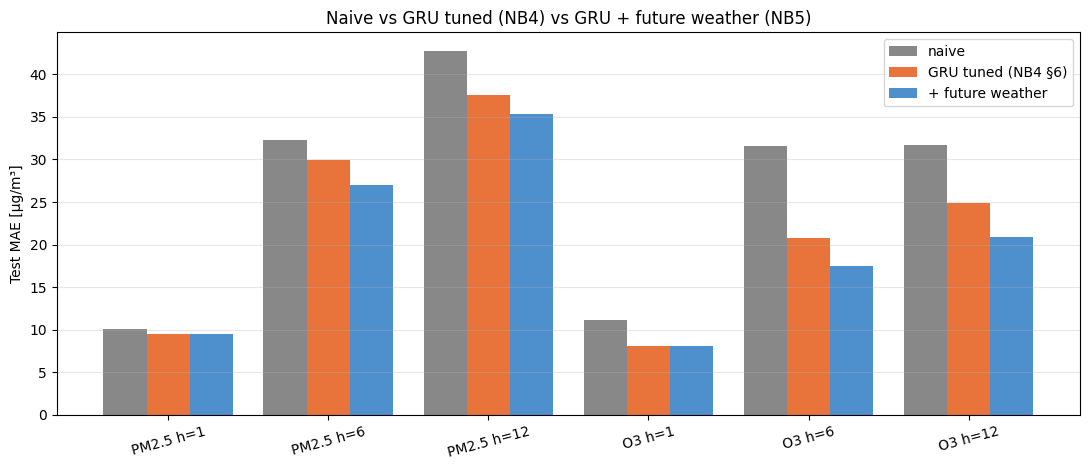

In [6]:
# Naive (best of persistence / seasonal-naive) reference numbers from NB2
# and GRU(32) tuned numbers from NB4 §6, kept hard-coded so the chart
# matches NB4 exactly (the in-notebook baseline run reproduces these to
# within 0.1 ug/m^3).
naive_ref = {
    ("PM2.5",  1): 10.11, ("PM2.5",  6): 32.29, ("PM2.5", 12): 42.80,
    ("O3",     1): 11.20, ("O3",     6): 31.59, ("O3",    12): 31.69,
}
nb4_tuned = {
    ("PM2.5",  1):  9.49, ("PM2.5",  6): 29.97, ("PM2.5", 12): 37.52,
    ("O3",     1):  8.11, ("O3",     6): 20.83, ("O3",    12): 24.91,
}

# Pull the future-informed run MAE values in the settings order (avoids
# pivot's alphabetical re-ordering of the pollutant index).
def mae(target, h, variant):
    m = (results.target == target) & (results.h == h) & (results.variant == variant)
    return float(results.loc[m, "MAE"].iloc[0])

naive_arr  = [naive_ref[(t, h)] for t, h in settings]
nb4_arr    = [nb4_tuned[(t, h)] for t, h in settings]
future_arr = [mae(t, h, "combined") for t, h in settings]

labels = [f"{t} h={h}" for t, h in settings]
x = np.arange(len(labels))
w = 0.27
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - w, naive_arr,  w, label="naive",                color="#888")
ax.bar(x,     nb4_arr,    w, label="GRU tuned (NB4 §6)",   color="#E8743B")
ax.bar(x + w, future_arr, w, label="+ future weather",     color="#4E8FCE")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Test MAE [µg/m³]")
ax.set_title("Naive vs GRU tuned (NB4) vs GRU + future weather (NB5)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

Three patterns to read off:

- ***h* = 1 shows essentially no gain** (within 0.1 &micro;g/m&sup3; either way). At one-hour horizon the model is already close to persistence; future weather at *t* + 6 and *t*+12 is far past the prediction time and adds noise without signal.
- ***h* = 6 and *h* = 12 improve clearly** &mdash; roughly 6&ndash;16 % relative MAE reduction depending on the setting. This is the largest single change we have seen across the entire module.
- **The harder the setting, the bigger the gain** &mdash; O&#8323; *h* = 12 goes from 24.9 to 20.9 &micro;g/m&sup3;, a ≈16 % cut. The R&sup2; jumps from 0.73 to 0.81.

Compare this to NB4. There, model-side tuning (Huber loss, Dropout) shaved roughly 2 &micro;g/m&sup3; off the default GRU on the hard settings. Here, switching to a *better input feature set* &mdash; the same model, just fed future weather &mdash; buys another **2&ndash;4 &micro;g/m&sup3;**, comparable to or larger than the model-tuning gain. The lever has shifted from the model to the inputs.


---
## 6. PM2.5 vs O&#8323; — different dominant drivers

We ran two extra variants alongside `baseline` and `combined`: **+wind only** (just the two wind-average scalars) and **+temp only** (just the two TEMP scalars). The decomposition tells us which half of the future information each pollutant cares about.

In [7]:
decomp = pivot[["target", "h", "baseline", "+wind", "+temp", "combined"]].copy()
for col in ["+wind", "+temp", "combined"]:
    decomp[col + "_delta"] = (decomp[col] - decomp["baseline"]).round(2)
decomp = decomp.round(2)
# Show only h=12 (where the gain is largest); decomposition pattern is
# the same at h=6 with smaller magnitudes.
print(decomp[decomp["h"] == 12].set_index(["target", "h"]).to_string())

variant    baseline  +wind  +temp  combined  +wind_delta  +temp_delta  combined_delta
target h                                                                             
O3     12     24.91  23.36  21.73     20.87        -1.55        -3.18           -4.04
PM2.5  12     37.52  34.73  37.61     35.33        -2.78         0.09           -2.19


Reading the decomposition (focus on *h* = 12 where the gain is largest):

**PM2.5 is wind-driven.** The +temp variant matches baseline almost exactly (delta +0.09); the +wind variant captures the entire gain on its own (delta &minus;2.78). Adding TEMP on top of wind actually *slightly hurts* (combined &minus;2.19 vs wind-alone &minus;2.78) — once wind is known, the extra TEMP signal is uncorrelated with what is left to predict and acts as noise during optimisation. PM2.5 is particulate matter — physical particles transported by the wind. Knowing where the wind will blow over the next 6 hours tells the model whether pollution is being advected toward or away from the station.

**O&#8323; is temperature-driven.** Removing future wind still leaves most of the gain — TEMP-only (&minus;3.18) is close to combined (&minus;4.04) — while removing future TEMP collapses the gain back near baseline (&minus;1.55 from wind alone). Tropospheric O&#8323; is formed by photochemical reactions between NO<sub>x</sub> and VOCs in the presence of sunlight, with reaction rates strongly modulated by temperature. Knowing future TEMP is essentially knowing future photochemistry intensity.

**Combined effects are roughly additive on O&#8323;** (&minus;1.55 wind + &minus;3.18 temp = &minus;4.73 if independent; combined is &minus;4.04, about 85 % of that — slight overlap because wind and temperature patterns are partially correlated). On **PM2.5** the picture is the opposite: TEMP and wind do not stack — TEMP is redundant, even mildly harmful, once wind is known.

---
## Recap

- **Better information beats more model tuning here.** Once the input set includes future weather, the same GRU(32) we used in NB4 cuts MAE by 6&ndash;16 % on the hard settings. The gain comes from **access to future information**, not better model capability &mdash; no new architecture, no new optimiser, no new loss.
- **Different pollutants are bottlenecked on different things.** PM2.5 needs to know future wind; O&#8323; needs to know future temperature. The combined gain decomposes cleanly along this textbook chemistry split.
- **The ceiling is empirical, not theoretical.** It depends on this model architecture, this dataset, and this 24-hour window. Model capacity, measurement noise, and unobserved system dynamics still limit what is achievable even with a zero-error look-ahead.

When a model has plateaued and a half-dozen architectures all sit within noise of each other, the next investment is almost always **inputs**, not weights.

### Check your understanding

1. We feed the model values that are not available at prediction time &mdash; this is **target leakage**. Why is it appropriate to do this here, and why would the same approach be a serious bug in a deployed system?
2. The combined future-informed setup beats baseline by &asymp;4 &mu;g/m&sup3; on O&#8323; *h* = 12, but we describe this as an **empirical ceiling under idealized information assumptions**, not a theoretical maximum. What additional sources of error remain, even with perfectly accurate future weather?
3. Why does adding **future TEMP** help O&#8323; substantially but help PM2.5 essentially zero? Connect your answer to the dominant physical driver of each pollutant.

*(Answers: 1 &mdash; Here it is intentional and quantified: we are measuring the value of future information under idealized conditions, not deploying. In production, using a value not yet known at prediction time leaks the target into the input and the model's reported error becomes meaningless. 2 &mdash; Model capacity (GRU(32) on 24-step windows), measurement noise in pollutant sensors, and unobserved drivers (traffic, emissions, regional transport) all remain &mdash; perfect future weather doesn't make any of those go away. 3 &mdash; PM2.5 is transport- and dispersion-driven, so wind dominates; O&#8323; is photochemically produced, so temperature (a proxy for solar radiation and reaction rate) dominates. Each pollutant's bottleneck is whichever future variable carries information about its dominant physical driver.)*
